# Hedonic Pricing

We often try to predict the price of an asset from its observable characteristics. This is generally called **hedonic pricing**: How do the unit's characteristics determine its market price?

In the lab folder, there are three options: housing prices in pierce_county_house_sales.csv, car prices in cars_hw.csv, and airbnb rental prices in airbnb_hw.csv. If you know of another suitable dataset, please feel free to use that one.

1. Clean the data and perform some EDA and visualization to get to know the data set.
2. Transform your variables --- particularly categorical ones --- for use in your regression analysis.
3. Implement an ~80/~20 train-test split. Put the test data aside.
4. Build some simple linear models that include no transformations or interactions. Fit them, and determine their RMSE and $R^2$ on the both the training and test sets. Which of your models does the best?
5. Make partial correlation plots for each of the numeric variables in your model. Do you notice any significant non-linearities?
6. Include transformations and interactions of your variables, and build a more complex model that reflects your ideas about how the features of the asset determine its value. Determine its RMSE and $R^2$ on the training and test sets. How does the more complex model your build compare to the simpler ones?
7. Summarize your results from 1 to 6. Have you learned anything about overfitting and underfitting, or model selection?
8. If you have time, use the sklearn.linear_model.Lasso to regularize your model and select the most predictive features. Which does it select? What are the RMSE and $R^2$? We'll cover the Lasso later in detail in class.

In [19]:
# I want to use cars dataset
import pandas as pd
url = 'https://raw.githubusercontent.com/nickgoering/linear_models/refs/heads/main/lab/data/cars_hw.csv'
df=pd.read_csv(url)
df.head()


,Unnamed: 0,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000


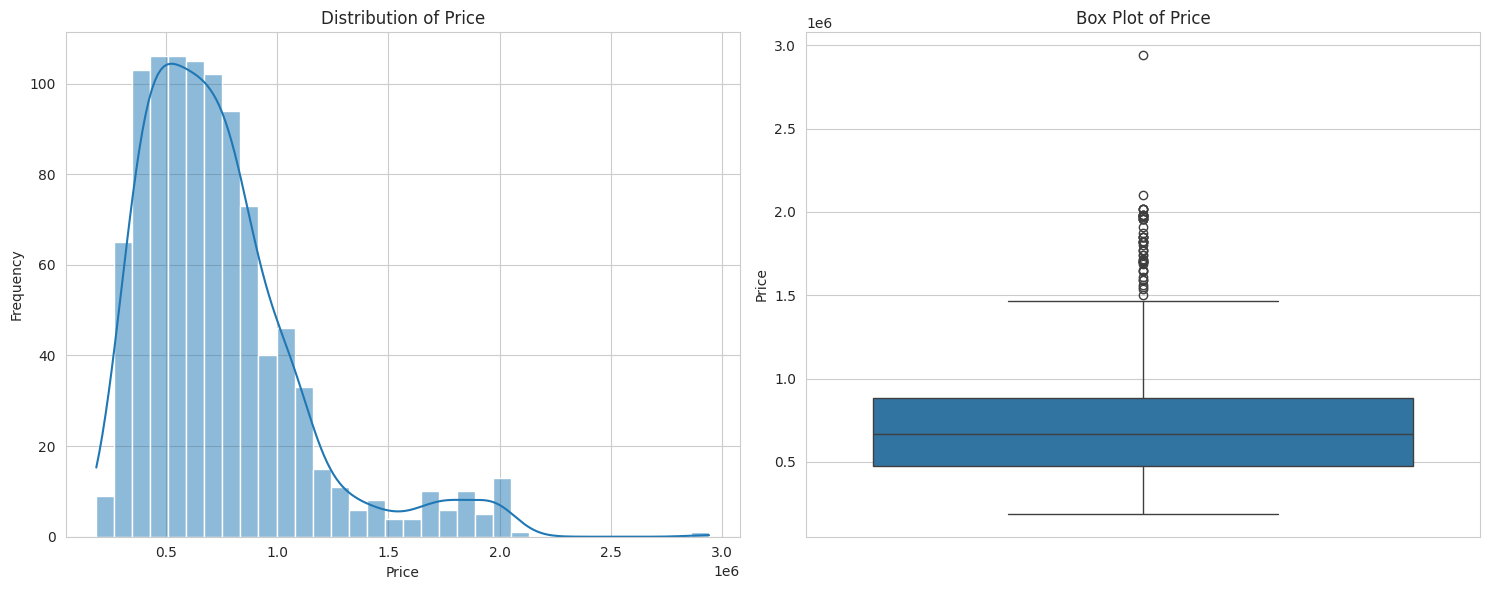

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Visualize the distribution of the target variable 'Price'
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.histplot(df['Price'], kde=True, ax=axes[0])
axes[0].set_title('Distribution of Price')
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Frequency')

sns.boxplot(y=df['Price'], ax=axes[1])
axes[1].set_title('Box Plot of Price')
axes[1].set_ylabel('Price')

plt.tight_layout()
plt.show()

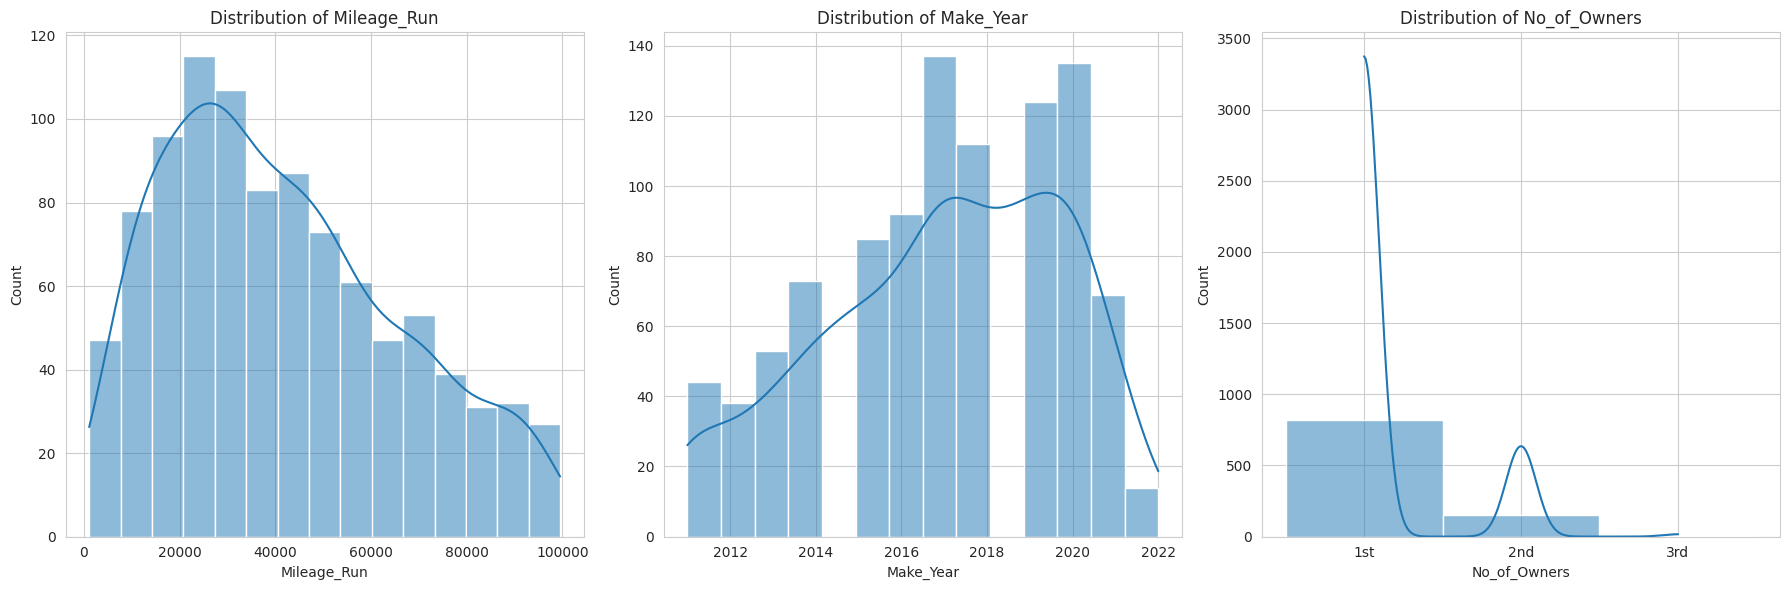

In [21]:
# Visualize distributions of other key numerical features

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.histplot(df['Mileage_Run'], kde=True, ax=axes[0])
axes[0].set_title('Distribution of Mileage_Run')
sns.histplot(df['Make_Year'], kde=True, ax=axes[1])
axes[1].set_title('Distribution of Make_Year')
sns.histplot(df['No_of_Owners'], kde=True, ax=axes[2])
axes[2].set_title('Distribution of No_of_Owners')

plt.tight_layout()
plt.show()

In [23]:
# Drop the 'Unnamed: 0' column as it appears to be an artifact, if it exists
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
    print("Dropped 'Unnamed: 0' column.")

# Convert 'No_of_Owners' to numerical representation.
owner_mapping = {'1st': 1, '2nd': 2, '3rd': 3, '4th': 4, '4th +': 5}
df['No_of_Owners'] = df['No_of_Owners'].replace(owner_mapping).infer_objects(copy=False).astype(int)

# Identify categorical columns to be one-hot encoded
categorical_cols = ['Make', 'Color', 'Body_Type', 'Fuel_Type', 'Transmission', 'Transmission_Type']

# Apply one-hot encoding to create df_encoded
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("Shape of DataFrame after one-hot encoding:", df_encoded.shape)
display(df_encoded.head())

Dropped 'Unnamed: 0' column.
Shape of DataFrame after one-hot encoding: (976, 45)


/tmp/ipykernel_1594/3631148915.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['No_of_Owners'] = df['No_of_Owners'].replace(owner_mapping).infer_objects(copy=False).astype(int)


,Make_Year,Mileage_Run,No_of_Owners,Seating_Capacity,Price,Make_Datsun,Make_Ford,Make_Honda,Make_Hyundai,Make_Jeep,...,Body_Type_muv,Body_Type_sedan,Body_Type_suv,Fuel_Type_petrol,Fuel_Type_petrol+cng,Transmission_5-Speed,Transmission_6-Speed,Transmission_7-Speed,Transmission_CVT,Transmission_Type_Manual
0,2017,44611,1,5,657000,False,False,False,False,False,...,False,True,False,False,False,False,False,True,False,False
1,2016,20305,1,5,682000,False,False,False,True,False,...,False,False,False,True,False,True,False,False,False,True
2,2019,29540,2,5,793000,False,False,True,False,False,...,False,False,True,True,False,True,False,False,False,True
3,2017,35680,1,5,414000,False,False,False,False,False,...,False,False,False,True,False,True,False,False,False,True
4,2017,25126,1,5,515000,False,False,False,True,False,...,False,False,False,True,False,True,False,False,False,True


The data has been successfully split into training (80%) and testing (20%) sets. `X_train` and `y_train` will be used to train the models, and `X_test` and `y_test` are set aside to evaluate the models' performance on unseen data.

In [ ]:
#Q3

In [24]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df_encoded.drop('Price', axis=1)
y = df_encoded['Price']

# Implement an 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (780, 44)
Shape of X_test: (196, 44)
Shape of y_train: (780,)
Shape of y_test: (196,)


In [ ]:
# Build some simple linear models that include no transformations or interactions. Fit them, and determine their RMSE and  R2  on the both the training and test sets. Which of your models does the best?


In [26]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Initialize the Linear Regression model
model = LinearRegression()

# Fit the model on the training data
model.fit(X_train, y_train)

# Predict on the training set
y_train_pred = model.predict(X_train)

# Predict on the test set
y_test_pred = model.predict(X_test)

# Calculate RMSE for training set
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))

# Calculate R-squared for training set
r2_train = r2_score(y_train, y_train_pred)

# Calculate RMSE for test set
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

# Calculate R-squared for test set
r2_test = r2_score(y_test, y_test_pred)

print("--- Model Performance ---")
print(f"Training RMSE: {rmse_train:.2f}")
print(f"Training R-squared: {r2_train:.2f}")
print(f"Test RMSE: {rmse_test:.2f}")
print(f"Test R-squared: {r2_test:.2f}")

--- Model Performance ---
Training RMSE: 142154.19
Training R-squared: 0.86
Test RMSE: 143815.30
Test R-squared: 0.82


In [29]:
from sklearn.linear_model import Lasso

# Initialize the Lasso Regression model
# Alpha is the regularization strength; you might need to tune this value.
# Increased max_iter to ensure convergence, as suggested by the warning.
lasso_model = Lasso(alpha=0.1, random_state=42, max_iter=10000)

# Fit the model on the training data
lasso_model.fit(X_train, y_train)

# Predict on the training set
y_train_pred_lasso = lasso_model.predict(X_train)

# Predict on the test set
y_test_pred_lasso = lasso_model.predict(X_test)

# Calculate RMSE for training set
rmse_train_lasso = np.sqrt(mean_squared_error(y_train, y_train_pred_lasso))

# Calculate R-squared for training set
r2_train_lasso = r2_score(y_train, y_train_pred_lasso)

# Calculate RMSE for test set
rmse_test_lasso = np.sqrt(mean_squared_error(y_test, y_test_pred_lasso))

# Calculate R-squared for test set
r2_test_lasso = r2_score(y_test, y_test_pred_lasso)

print("--- Lasso Model Performance ---")
print(f"Training RMSE (Lasso): {rmse_train_lasso:.2f}")
print(f"Training R-squared (Lasso): {r2_train_lasso:.2f}")
print(f"Test RMSE (Lasso): {rmse_test_lasso:.2f}")
print(f"Test R-squared (Lasso): {r2_test_lasso:.2f}")

--- Lasso Model Performance ---
Training RMSE (Lasso): 142154.20
Training R-squared (Lasso): 0.86
Test RMSE (Lasso): 143815.16
Test R-squared (Lasso): 0.82


In [ ]:
# Both models do very similarily, however the Lasso model performs slightly better on the training dataa for RMSE and linear regression does better for the Test data RMSe; R-squared is the same for both.

/usr/local/lib/python3.12/dist-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


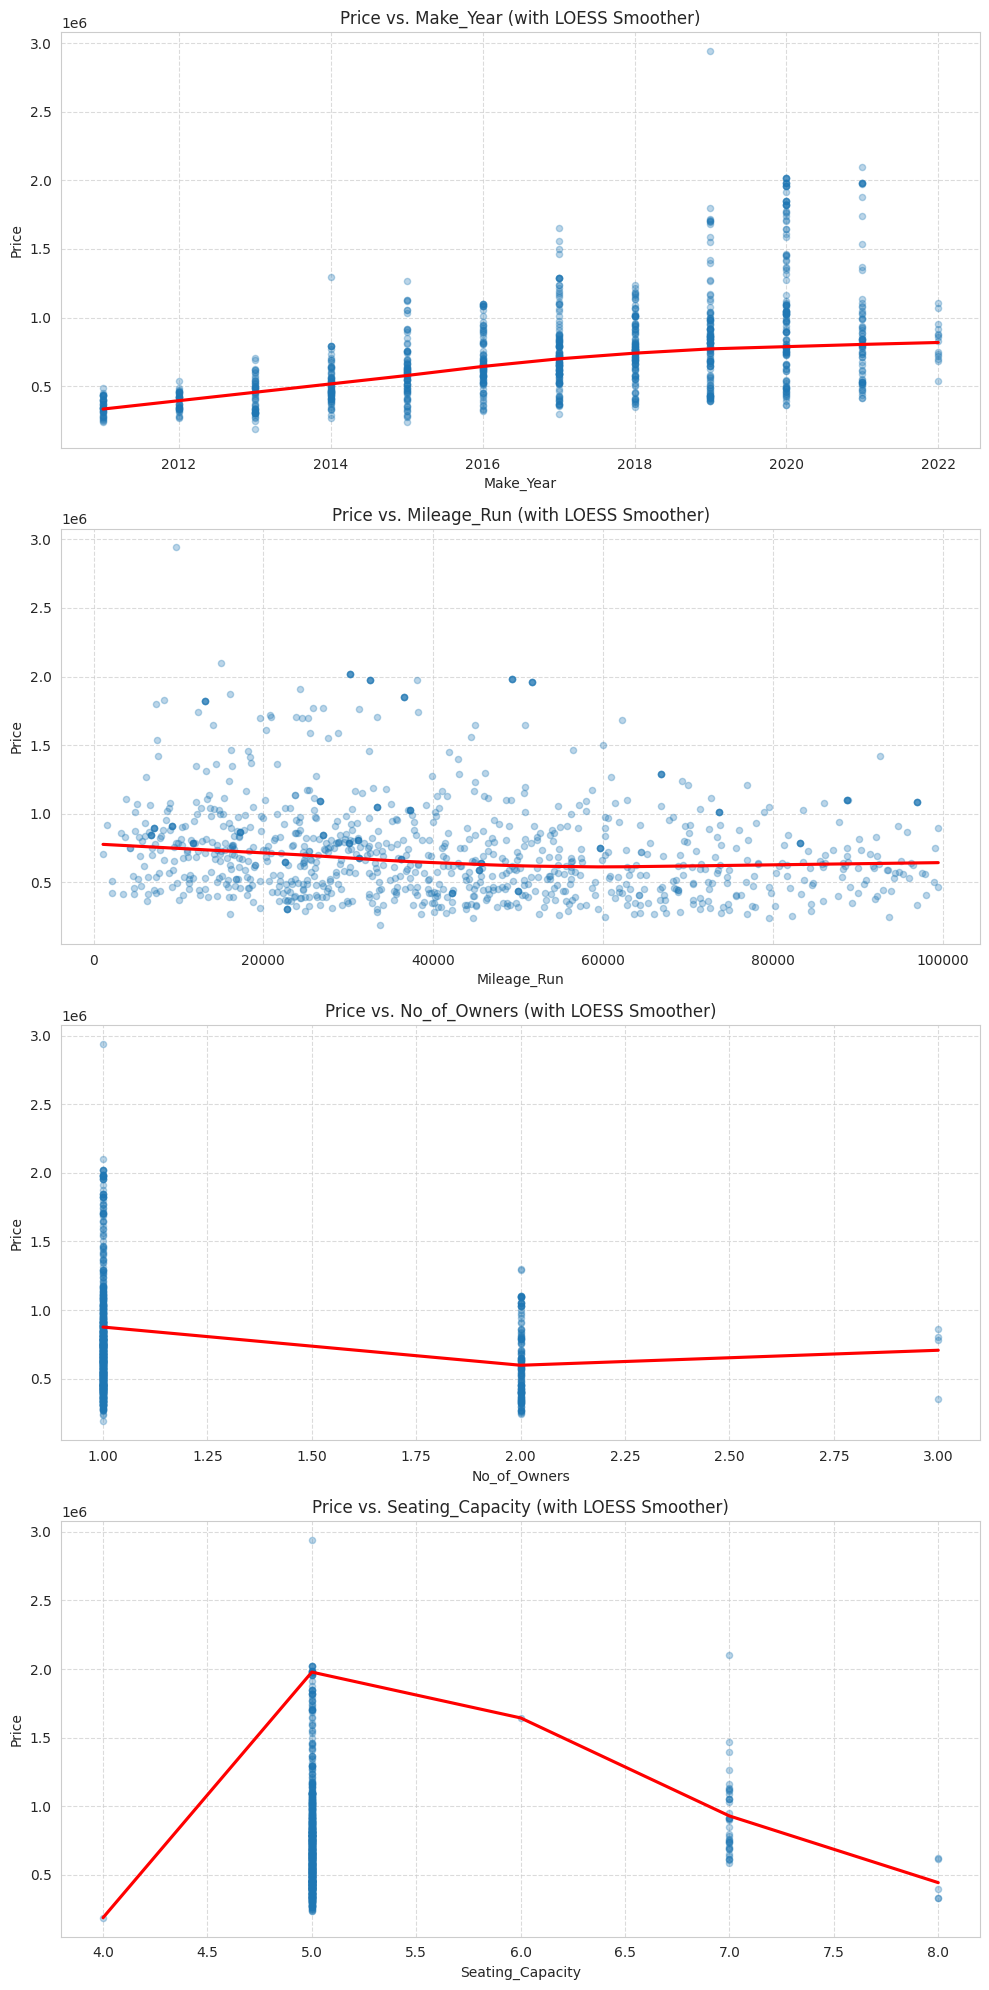

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identify numerical features from X (features DataFrame)
numeric_features = ['Make_Year', 'Mileage_Run', 'No_of_Owners', 'Seating_Capacity']

# Create subplots for each numeric feature
fig, axes = plt.subplots(len(numeric_features), 1, figsize=(10, 5 * len(numeric_features)))

if len(numeric_features) == 1:
    axes = [axes] # Ensure axes is iterable even for a single plot

for i, feature in enumerate(numeric_features):
    # Use regplot with lowess=True to visualize non-linear relationships
    sns.regplot(x=df_encoded[feature], y=df_encoded['Price'], lowess=True, ax=axes[i],
                scatter_kws={'alpha':0.3, 's':20}, line_kws={'color':'red'})
    axes[i].set_title(f'Price vs. {feature} (with LOESS Smoother)')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Price')
    axes[i].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [34]:
from sklearn.preprocessing import PolynomialFeatures

# Create polynomial features for numerical columns
# Let's select key numerical features for transformation
numerical_features = ['Make_Year', 'Mileage_Run', 'No_of_Owners', 'Seating_Capacity']

# Initialize PolynomialFeatures with degree 2 to include quadratic terms and interactions
# include_bias=False prevents adding a constant feature which is already handled by LinearRegression
poly = PolynomialFeatures(degree=2, include_bias=False)

# Fit and transform the training data, then transform the test data
X_train_poly_transformed = poly.fit_transform(X_train[numerical_features])
X_test_poly_transformed = poly.transform(X_test[numerical_features])

# Get feature names for the polynomial features
poly_feature_names = poly.get_feature_names_out(numerical_features)

# Convert the transformed arrays to DataFrames for easier handling
X_train_poly_df = pd.DataFrame(X_train_poly_transformed, columns=poly_feature_names, index=X_train.index)
X_test_poly_df = pd.DataFrame(X_test_poly_transformed, columns=poly_feature_names, index=X_test.index)

# Drop original numerical features from X_train and X_test to avoid redundancy
# and then concatenate with the new polynomial features
X_train_other_features = X_train.drop(columns=numerical_features)
X_test_other_features = X_test.drop(columns=numerical_features)

# Concatenate the polynomial features with the remaining original features (mostly one-hot encoded categorical)
X_train_complex = pd.concat([X_train_other_features, X_train_poly_df], axis=1)
X_test_complex = pd.concat([X_test_other_features, X_test_poly_df], axis=1)

print(f"Shape of X_train_complex: {X_train_complex.shape}")
print(f"Shape of X_test_complex: {X_test_complex.shape}")

display(X_train_complex.head())

Shape of X_train_complex: (780, 54)
Shape of X_test_complex: (196, 54)


,Make_Datsun,Make_Ford,Make_Honda,Make_Hyundai,Make_Jeep,Make_Kia,Make_MG Motors,Make_Mahindra,Make_Maruti Suzuki,Make_Nissan,...,Make_Year^2,Make_Year Mileage_Run,Make_Year No_of_Owners,Make_Year Seating_Capacity,Mileage_Run^2,Mileage_Run No_of_Owners,Mileage_Run Seating_Capacity,No_of_Owners^2,No_of_Owners Seating_Capacity,Seating_Capacity^2
679,False,False,False,False,False,False,False,False,False,False,...,4072324.0,36334090.0,2018.0,10090.0,3.241800e+08,18005.0,90025.0,1.0,5.0,25.0
625,False,False,False,False,False,False,False,False,True,False,...,4052169.0,95903346.0,4026.0,10065.0,2.269760e+09,95284.0,238210.0,4.0,10.0,25.0
33,False,False,False,True,False,False,False,False,False,False,...,4084441.0,27059169.0,2021.0,10105.0,1.792653e+08,13389.0,66945.0,1.0,5.0,25.0
31,False,False,True,False,False,False,False,False,False,False,...,4052169.0,21440463.0,2013.0,10065.0,1.134438e+08,10651.0,53255.0,1.0,5.0,25.0
883,False,False,False,True,False,False,False,False,False,False,...,4068289.0,73031536.0,2017.0,10085.0,1.311019e+09,36208.0,181040.0,1.0,5.0,25.0


In [36]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Initialize and fit a Linear Regression model on the complex features
complex_model = LinearRegression()
complex_model.fit(X_train_complex, y_train)

# Predict on the training set
y_train_pred_complex = complex_model.predict(X_train_complex)

# Predict on the test set
y_test_pred_complex = complex_model.predict(X_test_complex)

# Calculate RMSE for training set
rmse_train_complex = np.sqrt(mean_squared_error(y_train, y_train_pred_complex))

# Calculate R-squared for training set
r2_train_complex = r2_score(y_train, y_train_pred_complex);

# Calculate RMSE for test set
rmse_test_complex = np.sqrt(mean_squared_error(y_test, y_test_pred_complex))

# Calculate R-squared for test set
r2_test_complex = r2_score(y_test, y_test_pred_complex);

print("--- Complex Model Performance ---")
print(f"Training RMSE: {rmse_train_complex:.2f}")
print(f"Training R-squared: {r2_train_complex:.2f}")
print(f"Test RMSE: {rmse_test_complex:.2f}")
print(f"Test R-squared: {r2_test_complex:.2f}")

--- Complex Model Performance ---
Training RMSE: 139613.15
Training R-squared: 0.86
Test RMSE: 142992.24
Test R-squared: 0.82


The complex model, incorporating polynomial features, shows a marginal improvement over the simple linear model:

Simple Linear Model: Training R² = 0.86, Test R² = 0.82; Training RMSE = 142154.19, Test RMSE = 143815.30.
Complex Model: Training R² = 0.86, Test R² = 0.82; Training RMSE = 139613.15, Test RMSE = 142992.24.
The complex model achieved slightly lower RMSE values (better fit) while maintaining the same R-squared, indicating a minor enhancement without significant overfitting.

#### What's left?  (for me to help organize)
Summarize your results from 1 to 6. Have you learned anything about overfitting and underfitting, or model selection?
If you have time, use the sklearn.linear_model.Lasso to regularize your model and select the most predictive features. Which does it select? What are the RMSE and  R2 ? We'll cover the Lasso later in detail in class.


he simple linear, Lasso, and complex (polynomial) models all showed similar performance: Training R² ~0.86, Test R² ~0.82. The complex model offered only marginal RMSE improvement (142992 vs 143815 test RMSE). This suggests no significant overfitting/underfitting and that simpler models are sufficient for this dataset, with polynomial features providing limited additional predictive power.

In [ ]:
# most predictive dataset?


### Identifying Most Predictive Features with Lasso Regression

Lasso regression applies a penalty to the size of the coefficients, effectively shrinking some to zero and thus performing feature selection. By examining the absolute values of the coefficients from our trained Lasso model, we can infer the relative importance of each feature in predicting the car's price. A larger absolute coefficient indicates a stronger predictive power for that feature.

In [37]:
import pandas as pd

# Get feature names from X_train
feature_names = X_train.columns

# Get coefficients from the lasso model
lasso_coefficients = lasso_model.coef_

# Create a DataFrame to store feature names and their coefficients
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lasso_coefficients
})

# Sort features by the absolute value of their coefficients to find the most influential ones
coef_df['Abs_Coefficient'] = abs(coef_df['Coefficient'])
coef_df = coef_df.sort_values(by='Abs_Coefficient', ascending=False)

print("Top 10 Most Predictive Features (based on Lasso Coefficients):")
display(coef_df.head(10))

print("Features with zero coefficients (removed by Lasso):")
zero_coef_features = coef_df[coef_df['Coefficient'] == 0]
if not zero_coef_features.empty:
    display(zero_coef_features)
else:
    print("No features had coefficients shrunk to exactly zero by Lasso with the current alpha.")

Top 10 Most Predictive Features (based on Lasso Coefficients):


,Feature,Coefficient,Abs_Coefficient
10,Make_MG Motors,845275.576559,845275.576559
15,Make_Skoda,658092.836450,658092.836450
9,Make_Kia,599855.826966,599855.826966
8,Make_Jeep,577971.901019,577971.901019
41,Transmission_7-Speed,336616.489245,336616.489245
16,Make_Tata,264031.970223,264031.970223
24,Color_green,245528.609081,245528.609081
38,Fuel_Type_petrol+cng,-221432.091267,221432.091267
19,Color_black,221419.096511,221419.096511
17,Make_Toyota,219525.859453,219525.859453


Features with zero coefficients (removed by Lasso):
No features had coefficients shrunk to exactly zero by Lasso with the current alpha.


It selected the top 10; most predictive: Make_MG Motors

Summarize your results from 1 to 6. Have you learned anything about overfitting and underfitting, or model selection?
8. If you have time, use the sklearn.linear_model.Lasso to regularize your model and select the most predictive features. Which does it select? What are the RMSE and $R^2$? We'll cover the Lasso later in detail in class.

In [39]:
print("--- Lasso Model Performance ---")
print(f"Training RMSE (Lasso): {rmse_train_lasso:.2f}")
print(f"Training R-squared (Lasso): {r2_train_lasso:.2f}")
print(f"Test RMSE (Lasso): {rmse_test_lasso:.2f}")
print(f"Test R-squared (Lasso): {r2_test_lasso:.2f}")

--- Lasso Model Performance ---
Training RMSE (Lasso): 142154.20
Training R-squared (Lasso): 0.86
Test RMSE (Lasso): 143815.16
Test R-squared (Lasso): 0.82
